<a href="https://colab.research.google.com/github/Jay-PhDAI/PhDAI_732_GP1/blob/main/PhDAI732_GP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using snippets of code from https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb
example.

In [1]:
import sys
assert sys.version_info >= (3, 7)

from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
from sklearn.preprocessing import MinMaxScaler

from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import requests # Added requests library
import matplotlib.pyplot as plt

Function to download and import the dataset from my Github.

In [2]:
def load_taxi_data(filename):
    # Define the target path for the final parquet file
    final_parquet_dir = Path("datasets/taxi")
    # The file name as found in the GitHub repository
    source_filename = filename
    final_parquet_path = final_parquet_dir / source_filename

    # Ensure the target directory exists
    final_parquet_dir.mkdir(parents=True, exist_ok=True)

    # If the final parquet file does not exist, proceed with download
    if not final_parquet_path.is_file():

        # Correct URL for raw GitHub content, assuming 'main' branch and correct path within repo
        url = f"https://raw.githubusercontent.com/Jay-PhDAI/PhDAI_732_GP1/main/{source_filename}"

        # Define a temporary path to download the file to first
        temp_download_path = final_parquet_dir / source_filename

        print(f"Downloading data from: {url} using requests library")
        response = requests.get(url, stream=True)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        with open(temp_download_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded to: {temp_download_path}")

    else:
        print(f"File already exists: {final_parquet_path}. Skipping download.")

    # Directly read the final parquet file
    return pd.read_parquet(final_parquet_path)

Datasets for NYC green taxicab tripdata now will be downloaded. We are going to use the first 5 months of 2026,(I am only using the first month for testing) and concatenate them into one dataframe.
Then we want to get some info about the dataset. Taking a peek at the dataset:

In [3]:
taxi1 = load_taxi_data("green_tripdata_2026-01.parquet")
taxi2 = load_taxi_data("green_tripdata_2026-02.parquet")
taxi3 = load_taxi_data("green_tripdata_2026-03.parquet")
taxi4 = load_taxi_data("green_tripdata_2026-04.parquet")
taxi5 = load_taxi_data("green_tripdata_2026-05.parquet")

taxi = pd.concat([taxi1, taxi2, taxi3, taxi4, taxi5])
# making an unadulterated copy of the concatenated dataframe
taxi_copy = taxi

Downloaded to: datasets/taxi/green_tripdata_2026-01.parquet
Downloaded to: datasets/taxi/green_tripdata_2026-02.parquet
Downloaded to: datasets/taxi/green_tripdata_2026-03.parquet
Downloaded to: datasets/taxi/green_tripdata_2026-04.parquet
Downloaded to: datasets/taxi/green_tripdata_2026-05.parquet


We need some sort of problem to solve. I think it would be interesting to try to determine what time of day is the best for a driver to earn tips.

<class 'pandas.core.frame.DataFrame'>
Index: 211012 entries, 0 to 44920
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               211012 non-null  int32         
 1   lpep_pickup_datetime   211012 non-null  datetime64[us]
 2   lpep_dropoff_datetime  211012 non-null  datetime64[us]
 3   store_and_fwd_flag     181457 non-null  object        
 4   RatecodeID             181457 non-null  float64       
 5   PULocationID           211012 non-null  int32         
 6   DOLocationID           211012 non-null  int32         
 7   passenger_count        181457 non-null  float64       
 8   trip_distance          211012 non-null  float64       
 9   fare_amount            211012 non-null  float64       
 10  extra                  211012 non-null  float64       
 11  mta_tax                211012 non-null  float64       
 12  tip_amount             211012 non-null  float64   

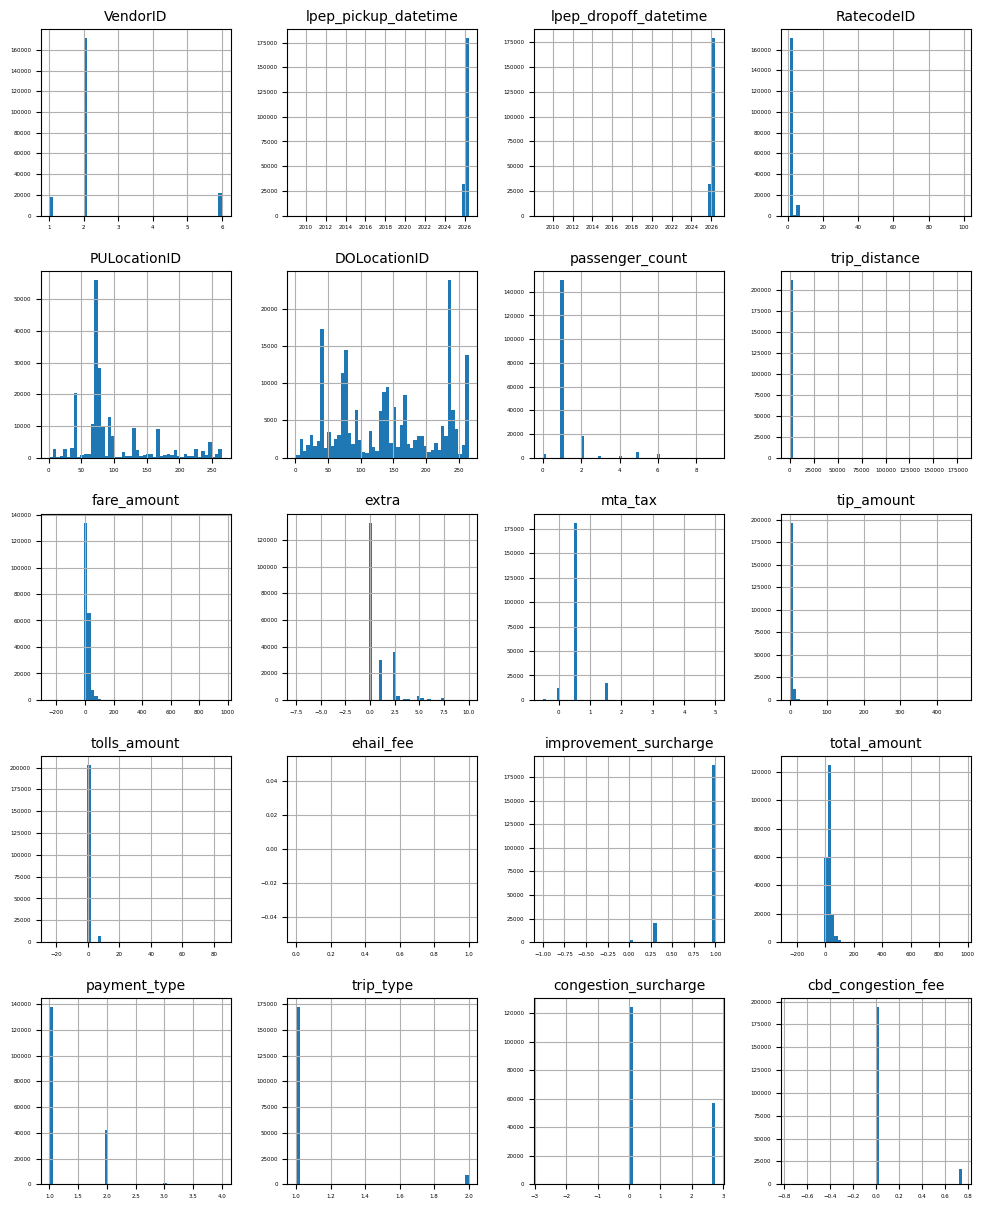

scaled_date
0.996046    56
0.985827    54
0.993848    54
0.992747    53
0.982851    52
            ..
0.977408     1
0.977406     1
0.977405     1
0.977397     1
0.977394     1
Name: count, Length: 12500, dtype: int64
lpep_dropoff_datetime
2026-02-20 00:00:00    6
2026-04-22 00:00:00    5
2026-01-20 00:00:00    4
2026-06-01 00:00:00    4
2026-05-12 18:28:44    4
                      ..
2026-02-27 18:44:05    1
2026-02-27 18:25:10    1
2026-02-27 18:49:54    1
2026-02-27 18:10:59    1
2026-02-27 19:23:31    1
Name: count, Length: 207767, dtype: int64


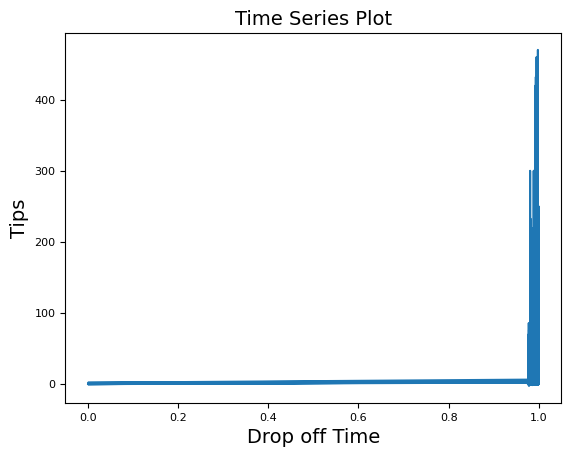

In [4]:
# get some initial info about the dataframe
taxi.info()
taxi.describe()
taxi.lpep_dropoff_datetime.info()

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=10)
plt.rc('axes', labelsize=10, titlesize=10)
plt.rc('legend', fontsize=10)
plt.rc('xtick', labelsize=4)
plt.rc('ytick', labelsize=4)

taxi.hist(bins=50, figsize=(12, 15))
plt.show()

#taxi['lpep_dropoff_datetime'] = pd.to_datetime(taxi['lpep_dropoff_datetime'])
#taxi['month'] = taxi['lpep_dropoff_datetime'].dt.month
#taxi['year'] = taxi['lpep_dropoff_datetime'].dt.year

# 1. Convert to datetime
taxi['lpep_dropoff_datetime'] = pd.to_datetime(taxi['lpep_dropoff_datetime'])

# 2. Convert to Unix timestamp (integer seconds)
taxi['timestamp'] = taxi['lpep_dropoff_datetime'].astype('int64') // 10**9

# 3. Scale the timestamps
from sklearn.preprocessing import MinMaxScaler
taxi[['scaled_date']] = MinMaxScaler().fit_transform(taxi[['timestamp']])

print(taxi.scaled_date.value_counts())
print(taxi['lpep_dropoff_datetime'].value_counts())

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=8)
plt.rc('ytick', labelsize=8)


plt.plot(taxi.scaled_date, taxi.tip_amount)
plt.xlabel('Drop off Time')
plt.ylabel('Tips')
plt.title('Time Series Plot')
plt.show()

Hmm I think we need to figure out some way to cluster the data better? Maybe do tips per hour of the day (0000 - 2359) so Hour 0 to 23. I dont see how the normalized scaled_date will be of use it is heavily skewed.
Maybe look at averages of tips per hour.

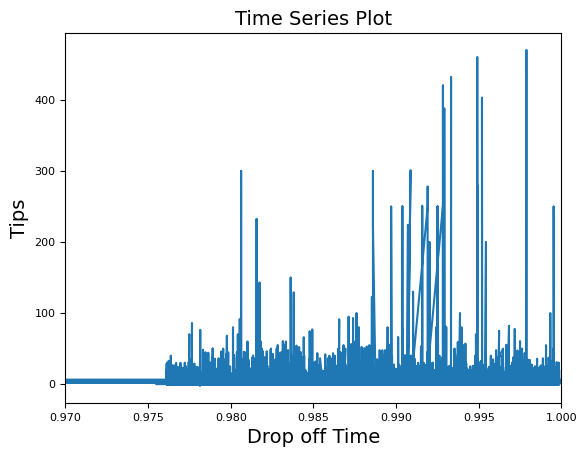

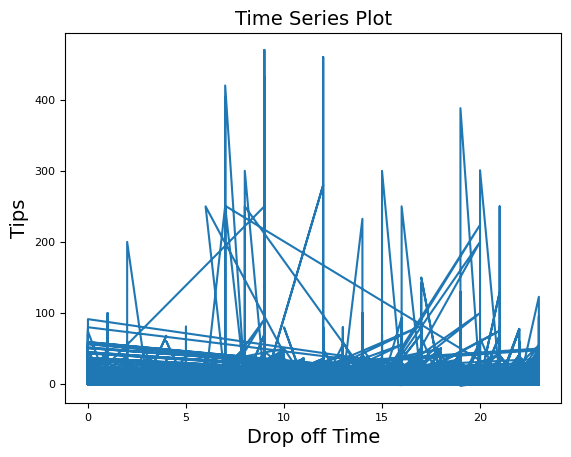

lpep_dropoff_datetime
2026-02-20 00:00:00    6
2026-04-22 00:00:00    5
2026-01-20 00:00:00    4
2026-06-01 00:00:00    4
2026-05-12 18:28:44    4
                      ..
2026-02-27 18:44:05    1
2026-02-27 18:25:10    1
2026-02-27 18:49:54    1
2026-02-27 18:10:59    1
2026-02-27 19:23:31    1
Name: count, Length: 207767, dtype: int64


In [5]:
plt.plot(taxi.scaled_date, taxi.tip_amount)
plt.xlabel('Drop off Time')
plt.ylabel('Tips')
plt.title('Time Series Plot')
plt.xlim(0.97,1)
plt.show()

# trying to group items by hour 0-24
plt.plot(taxi['lpep_dropoff_datetime'].dt.hour, taxi.tip_amount)
plt.xlabel('Drop off Time')
plt.ylabel('Tips')
plt.title('Time Series Plot')
plt.show()

taxi['lpep_dropoff_datetime'] = pd.to_datetime(taxi['lpep_dropoff_datetime'])
print(taxi.lpep_dropoff_datetime.value_counts())


hour
0     2.937761
1     2.313900
2     2.807797
3     3.136296
4     2.712275
5     1.861111
6     1.834852
7     2.067781
8     2.432628
9     2.482463
10    2.457621
11    2.343887
12    2.233980
13    2.181958
14    2.286753
15    2.385745
16    2.566334
17    2.646057
18    2.645672
19    2.695940
20    2.538248
21    2.639965
22    2.879450
23    2.758815
Name: tip_amount, dtype: float64


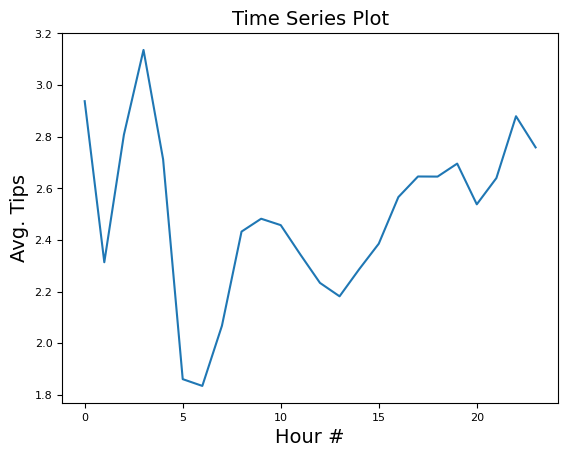

In [13]:
test = taxi1
test['lpep_dropoff_datetime'] = pd.to_datetime(test['lpep_dropoff_datetime'])
test['hour'] = test['lpep_dropoff_datetime'].dt.hour
#print(test['hour'].value_counts())
print(test.groupby('hour')['tip_amount'].mean())


#plt.plot(test['lpep_dropoff_datetime'].dt.hour, test.tip_amount)
plt.plot(test.groupby('hour')['tip_amount'].mean())
plt.xlabel('Hour #')
plt.ylabel('Avg. Tips')
plt.title('Time Series Plot')
plt.show()